# Homework - Session 2

### 1. Variance in a Population and Variance in a Sample

We can manually code the calculation of the variance of a list of numbers using the formula:
$$\sigma^2 = {\frac {1}{n}}\sum_{i=1}^{n} (x_{i}-\bar{x})^2$$

Strictly speaking, this formula is valid when calculating **population
variance**. If we only observe a sample of the population, we do not
calculate the variance but estimate it, and we must then use the
following formula to obtain an **unbiased estimator of the true
variance**: $$s^2 = {\frac {1}{n-1}}\sum_{i=1}^{n} (x_{i}-\bar{x})^2$$.

To account for this distinction:

-   code a `mean` function that calculates the mean of x
-   code a `var` function that calculates the variance of x (calling the `mean` function to calculate
    the mean)
-   modify the `var` function to allow the user to choose the
    calculation method via an optional `mode` parameter (default value:
    ‘population’ for calculation using the population formula;
    alternative value: ‘sample’ for calculation using the sample
    formula)

Using the list `x = [8, 18, 6, 0, 15, 17.5, 9, 1]` compare the values obtained in both cases with what the *black box*
function `var` from the `numpy` library returns (see the solution to the
previous tutorial exercise for the syntax, and see the
[doc](https://numpy.org/doc/stable/reference/generated/numpy.var.html)
of the function, especially the `ddof` parameter to vary the calculation
method).

In [13]:
# import required packages:
import numpy as np

# Code a mean function:
def meanx(x):
    sumx = 0
    for val in x:
        sumx += val
    return sumx / len(x)

# Code a var function with an optional argument ddof to specify the number of degrees of freedom: 
def varx(x, ddof=0):
    mu = meanx(x)
    sst = 0
    for val in x:
        sdiff = (val-mu)**2
        sst += sdiff
    return sst / (len(x) - ddof)


# Compare variances: 

x = [8, 18, 6, 0, 15, 17.5, 9, 1]

print("The population variance is: ", varx(x))
print("The sample variance is: ", varx(x, ddof=1))
print("The population variance obtained with np.var() is: ", np.var(x))
print("The sample variance obtained with np.var() is: ", np.var(x, ddof=1))



The population variance is:  42.93359375
The sample variance is:  49.066964285714285
The population variance obtained with np.var() is:  42.93359375
The sample variance obtained with np.var() is:  49.066964285714285


### 2. Deforestation in Madagascar

1. Upload the Vahatra_defor_noNA database from Moodle.
2. Print it.
3. Display the list of all column names.
4. Shorten the column names which end with the suffix "-01-01_treecover_ha".
5. Compute the average deforestation rate over the period 2010-2020 and assign it to a new column (hint: we want $(treecover_{2010}-treecover_{2020})/treecover_{2010}*100$).
6. Create a scatter plot of the deforestation rate and the initial forested area of the protected areas.
7. Create a scatter plot of the deforestation rate and the distance to the closest city.

In [14]:
# load packages

import pandas as pd
from matplotlib.pyplot import subplots

!pip install openpyxl
import openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]


In [15]:
### 1 and 2. Upload the Vahatra_defor_noNA database and print it

pa_data = pd.read_excel('Vahatra_defor_noNA.xlsx')
pa_data

,nom,cat_iucn,creation,date_creation,date_modification,mention_changement,hectares,num_atlas_,full_name,province,...,traveltime_2015-01-01_5k_110mio_traveltime_mean_minutes,geometry,Groupe,surface_m2,surface_ha,surface_km2,couv_foret_2000,altitude,pente,dist_ville
0,Ambatotsirongorongo,V,Décret n°2015-792 du 28 avril 2015,2015-04-28,NaT,False,1030.048,62,Réserve Spéciale d'Ambatotsirongorongo\n,Toliary,...,69.769231,NaN,Contrôle,1.031541e+07,1031.541284,10.315413,62.863476,355.972801,21.815344,69.769231
1,Ambohidray,NaN,Décret n°2015-808 du 5 mai 2015,2015-05-05,NaT,False,1241.048,38,Nouvelle Aire Protégée d'Ambohidray,Toamasina,...,79.133333,NaN,Contrôle,1.245148e+07,1245.147815,12.451478,82.333465,1014.534544,13.000551,79.133333
2,Ambohijanahary,IV,Créée depuis le 28 octobre 1958,1958-10-28,NaT,False,24302.027,72,Réserve Spéciale d'Ambohijanahary\n,"Mahajanga, Toliary\n",...,308.898649,NaN,Traitement,2.439243e+08,24392.427213,243.924272,57.968125,926.475696,10.273493,308.898649
3,Bemarivo,IV,Créée le 10 septembre 1956,1956-09-10,NaT,False,12046.314,79,Réserve Spéciale de Bemarivo,Mahajanga,...,202.917808,NaN,Traitement,1.207558e+08,12075.580729,120.755807,62.838341,65.435098,3.268033,202.917808
4,Corridor Forestier Bongolava,NaN,Décret n°2015-790 du 28 avril 2015,2015-04-28,NaT,False,60589.816,63,Paysage Harmonieux Protégé du Corridor Foresti...,Mahajanga,...,87.317935,NaN,Contrôle,6.085824e+08,60858.238318,608.582383,38.641432,170.317400,4.769501,87.317935
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,Amoron'i Onilahy,V,Décret n°2015-788 du 28 avril 2015,2015-04-28,NaT,False,102071.884,94,Paysage Harmonieux Protégé d'Amoron'i Onilahy,Toliary,...,57.530876,NaN,Contrôle,1.023960e+09,102396.027307,1023.960273,8.154173,149.816833,5.099256,57.530876
93,Ankodida,V,Décret n°2015-787 du 28 avril 2015,2015-04-28,NaT,False,10628.513,60,Paysage Harmonieux Protégé d'Ankodida,Toliary,...,25.173913,NaN,Contrôle,1.064691e+08,10646.914347,106.469143,14.478495,94.041676,7.157048,25.173913
94,COMATSA Nord,VI,Décret n°2015-782 du 28 avril 2015,2015-04-28,NaT,False,238176.879,11,Réserve de Ressources Naturelles du Corridor M...,"Antsiranana, Mahajanga",...,519.426276,NaN,Contrôle,2.391992e+09,239199.156533,2391.991565,96.487930,1296.093544,18.871804,519.426276
95,COMATSA Sud,V,Décret n°2015-782 du 28 avril 2015,2015-04-28,NaT,False,82234.065,20,Paysage Harmonieux Protégé du Corridor Marojej...,"Antsiranana, Mahajanga",...,622.444779,NaN,Contrôle,8.257422e+08,82574.222974,825.742230,95.240031,1484.991585,17.204519,622.444779


In [16]:
### 3. Print list of dataframe columns
pa_data.columns

Index(['nom', 'cat_iucn', 'creation', 'date_creation', 'date_modification',
       'mention_changement', 'hectares', 'num_atlas_', 'full_name', 'province',
       'region', 'district', 'gest_1', 'gest_2', 'type_ap', 'an_creation',
       'assetid', 'elevation_2000-02-01_elevation_mean_m',
       'slope_2000-02-01_slope_mean_degrees',
       'treecover_area_2000-01-01_treecover_ha',
       'treecover_area_2001-01-01_treecover_ha',
       'treecover_area_2002-01-01_treecover_ha',
       'treecover_area_2003-01-01_treecover_ha',
       'treecover_area_2004-01-01_treecover_ha',
       'treecover_area_2005-01-01_treecover_ha',
       'treecover_area_2006-01-01_treecover_ha',
       'treecover_area_2007-01-01_treecover_ha',
       'treecover_area_2008-01-01_treecover_ha',
       'treecover_area_2009-01-01_treecover_ha',
       'treecover_area_2010-01-01_treecover_ha',
       'treecover_area_2011-01-01_treecover_ha',
       'treecover_area_2012-01-01_treecover_ha',
       'treecover_area_2013

In [18]:
### 4. Rename treecover columns
pa_data.columns = pa_data.columns.str.replace("-01-01_treecover_ha", "", regex=False)
pa_data.columns

Index(['nom', 'cat_iucn', 'creation', 'date_creation', 'date_modification',
       'mention_changement', 'hectares', 'num_atlas_', 'full_name', 'province',
       'region', 'district', 'gest_1', 'gest_2', 'type_ap', 'an_creation',
       'assetid', 'elevation_2000-02-01_elevation_mean_m',
       'slope_2000-02-01_slope_mean_degrees', 'treecover_area_2000',
       'treecover_area_2001', 'treecover_area_2002', 'treecover_area_2003',
       'treecover_area_2004', 'treecover_area_2005', 'treecover_area_2006',
       'treecover_area_2007', 'treecover_area_2008', 'treecover_area_2009',
       'treecover_area_2010', 'treecover_area_2011', 'treecover_area_2012',
       'treecover_area_2013', 'treecover_area_2014', 'treecover_area_2015',
       'treecover_area_2016', 'treecover_area_2017', 'treecover_area_2018',
       'treecover_area_2019', 'treecover_area_2020', 'treecover_area_2021',
       'treecover_area_2022', 'treecover_area_2023',
       'traveltime_2015-01-01_5k_110mio_traveltime_mean_

In [20]:
### 5. Compute deforestation rate and add it to a column named 'deforest_2000_2023':
pa_data['deforest_2000_2023'] = (pa_data['treecover_area_2010']-pa_data['treecover_area_2020'])/pa_data['treecover_area_2010']*100
pa_data['deforest_2000_2023'].describe()

count    97.000000
mean      8.719429
std      10.666220
min       0.000000
25%       1.270960
50%       5.012341
75%      13.115506
max      60.970014
Name: deforest_2000_2023, dtype: float64

Text(0.5, 1.0, 'Plot of deforestation rate vs intial forested area')

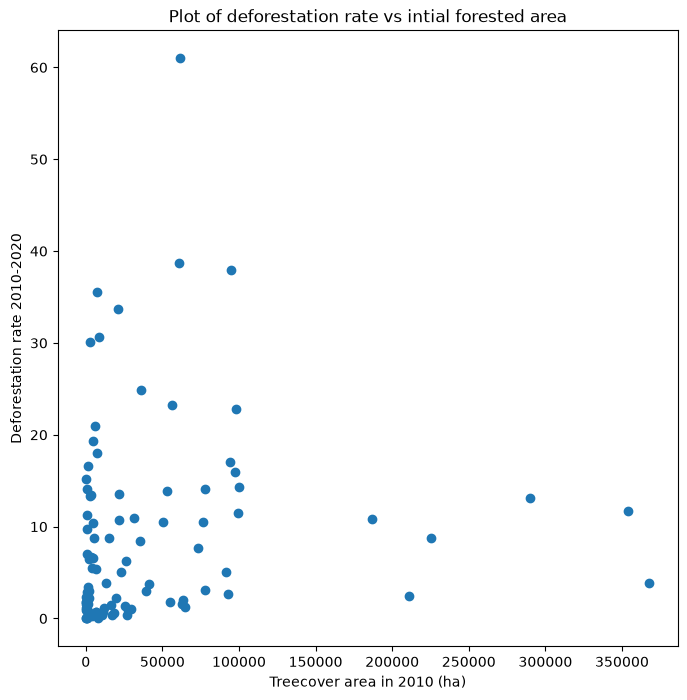

In [21]:
### 6. Scatter plot of deforestation rate and inital forested area
fig, axis = subplots(figsize=(8,8))
axis.scatter(pa_data['treecover_area_2010'],pa_data['deforest_2000_2023'], marker='o')
axis.set_xlabel("Treecover area in 2010 (ha)")
axis.set_ylabel("Deforestation rate 2010-2020")
axis.set_title("Plot of deforestation rate vs intial forested area")

Text(0.5, 1.0, 'Plot of deforestation rate vs travel time to the closest city in 2000')

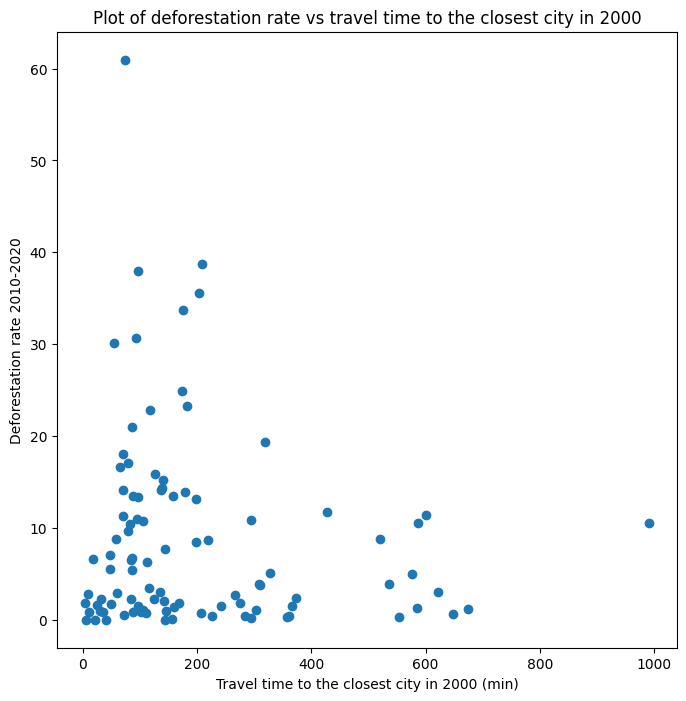

In [17]:
### 7. Scatter plot of deforestation rate and travel-time to the closest city in 2000
fig, axis = subplots(figsize=(8,8))
axis.scatter(pas['dist_ville'],pas['deforest_2000_2023'], marker='o')
axis.set_xlabel("Travel time to the closest city in 2000 (min)")
axis.set_ylabel("Deforestation rate 2010-2020")
axis.set_title("Plot of deforestation rate vs travel time to the closest city in 2000")